In [4]:
import scanpy, scprep
import pandas as pd
import numpy as np
import phate

import sys
sys.path.append('..')
from run.run_gspa import calculate_wavelet_dictionary
from run.run_ae_default_config import run_ae
from utils import *
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
import leidenalg
import graphtools
import networkx as nx
from scipy.stats import spearmanr
import magic
from scipy.spatial.distance import pdist, squareform

/home/aarthivenkat/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [7]:
data_int = scanpy.read_h5ad('data/int.h5ad')
data_gc = scanpy.read_h5ad('data/GC.h5ad')
hits = pd.read_csv('data/tf_hits.csv', index_col=0)
guide_hit_signal = hits.columns[np.where(hits.values > 0)[1]]
guides = hits.columns

/home/aarthivenkat/.local/lib/python3.8/site-packages/anndata/compat/__init__.py:229: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


In [3]:
embeddings = {}
for guide in guides:
    genes = np.load(f'results/{guide}_GSPA.npz', allow_pickle=True)['genes']
    embeddings[guide] = pd.DataFrame(np.load(f'results/{guide}_GSPA.npz')['signal_embedding'], index=genes)

In [4]:
localizations = {}
for guide in guides:
    genes = np.load(f'results/{guide}_GSPA.npz', allow_pickle=True)['genes']
    localizations[guide] = pd.DataFrame(np.load(f'results/{guide}_GSPA.npz')['localization_score'], index=genes)

## Edges in perturbation that are not in normal

In [6]:
for guide in guides:
    print (guide)
    threshold = np.percentile(localizations['NEG'], q=75)
    neg_loc = embeddings['NEG'].loc[(localizations['NEG'] > threshold)[0]]
    
    threshold = np.percentile(localizations[guide], q=75)
    KO_loc = embeddings[guide].loc[(localizations[guide] > threshold)[0]]
    
    loc_genes_both = set(neg_loc.index).intersection(KO_loc.index)
    
    G = graphtools.Graph(embeddings['NEG'].loc[loc_genes_both], knn=100, use_pygsp=True)
    G_neg = G.A.todense().astype(int)
    G = graphtools.Graph(embeddings[guide].loc[loc_genes_both], knn=5, use_pygsp=True)
    G_KO = G.A.todense().astype(int)
    
    A = G_KO - G_neg
    A = A > 0 # edges that are in KO graph and not in complete graph
    G_KO_only = nx.Graph(A)
    G_KO_only = nx.relabel_nodes(G_KO_only, dict(zip(range(G_KO_only.number_of_nodes()), list(loc_genes_both))))
    
    nx.write_edgelist(G_KO_only, f'results/{guide}_only_graph.tsv', delimiter='\t', data=False)
    
    for cc in nx.connected_components(G_KO_only):
        if len(cc) > 1:
            print (cc)

BACH2
{'Crip1', 'Tagln2', 'Plac8'}
BATF
{'Rplp0', 'Rps20'}
BCL6
{'Acot7', 'Etfb'}
{'Ifngr1', 'Hsp90aa1'}
CXCL13
{'Trbc1', 'Epsti1', 'Ccr2'}
{'Rcbtb2', 'Gm8369', 'Clec4a3'}
{'Ms4a4c', 'Rps11'}
{'Klhl6', 'Hsp90aa1'}
CXCR5
DNMT1
DNMT3A
DNMT3B
{'Cd28', 'Hsp90aa1'}
{'Dnmt1', 'Stat1'}
{'Gm45442', 'Ppia', 'Tsks'}
{'Rom1', 'Plac8'}
{'Tpi1', 'Igtp', 'Ifi213', 'Ifi47'}
{'Rpl12', 'Rps20'}
DUSP4
{'Cdkn3', 'S100a9', 'Fkbp2'}
{'Dap', 'Ncaph', 'Aspm'}
{'Sirpa', 'S100a10'}
{'Ccdc34', 'Tmsb10'}
{'Gzmb', 'Troap'}
EOMES
EZH2
{'Dnmt1', 'Arhgap15', 'Neurl3'}
ID2
{'Ctla4', 'Id3'}
{'Snx24', 'Cd28', 'Ctla2b', 'Mif', 'Gstp3'}
{'Lilr4b', 'Serpina3g', 'Dock2', 'Pdcd1'}
{'Rpl12', 'Rps20'}
ID3
IKZF1
IKZF2
{'Lig1', 'Tmsb10'}
IKZF3
{'Cd7', 'Rps12'}
IL21R
{'Trbc1', 'Cdc25b', 'Gm8369'}
{'Tnfsf8', 'Ccr2'}
{'Cd69', 'Dock2'}
IRF4
KLF2
{'Chil5', 'Fcgr2b'}
{'Ms4a4b', 'Zfp36l2', 'Hexb', 'Cmss1', 'Tpt1', 'Ier3'}
{'Hnrnpab', 'Vim', 'Rasgrp2', 'Lgals1', 'Reep5', 'Prf1', 'H2afz', 'Emp3', 'Klf2', 'Tagln2'}
{'CAAA01147332.1', 'Ad

In [5]:
guide = 'KLF2'

In [8]:
data = data_int[guide_hit_signal == guide].to_df()
# get graph of cells for hit
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30, verbose=False)
KO_phate = phate_op.fit_transform(data)
KO_magic = magic.MAGIC().fit_transform(data, graph=phate_op.graph)

Calculating MAGIC...
  Running MAGIC on 966 cells and 1795 genes.
  Using precomputed graph and diffusion operator...
  Calculating imputation...
  Calculated imputation in 0.06 seconds.
Calculated MAGIC in 0.07 seconds.


/home/aarthivenkat/.local/lib/python3.8/site-packages/magic/magic.py:425: UserWarning: Input matrix contains unexpressed genes. Please remove them prior to running MAGIC.
  warnings.warn(


In [9]:
data = data_int[guide_hit_signal == 'NEG'].to_df()
# get graph of cells for hit
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30, verbose=False)
NEG_phate = phate_op.fit_transform(data)
NEG_magic = magic.MAGIC().fit_transform(data, graph=phate_op.graph)

Calculating MAGIC...
  Running MAGIC on 3311 cells and 1795 genes.
  Using precomputed graph and diffusion operator...
  Calculating imputation...


/home/aarthivenkat/.local/lib/python3.8/site-packages/magic/magic.py:425: UserWarning: Input matrix contains unexpressed genes. Please remove them prior to running MAGIC.
  warnings.warn(


  Calculated imputation in 1.87 seconds.
Calculated MAGIC in 1.88 seconds.


<AxesSubplot:title={'center':'cell_clusters'}>

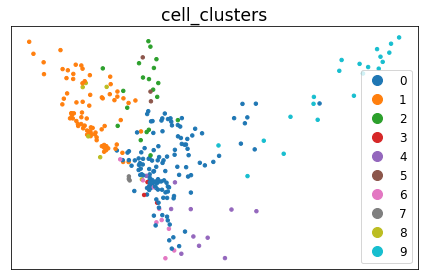

In [8]:
scprep.plot.scatter2d(KO_phate, c=data_int[guide_hit_signal == guide].obs['integrated_snn_res.0.3'],
                      title='cell_clusters', ticks=None)

In [13]:
KO_markers = [{'Kif22', 'Cd86'}, {'Rpl41', 'Cd7'}, {'Dock2', 'Ccr2', 'Rom1', 'Cdc25b'}, {'Gimap7', 'Dusp2', 'Ran', 'Tbx21', 'Bcl2a1a', 'Ctsw', 'H2-K1', 'Itga4', 'Prkch', 'Hnrnpa2b1'}]

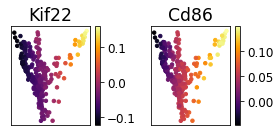

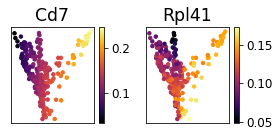

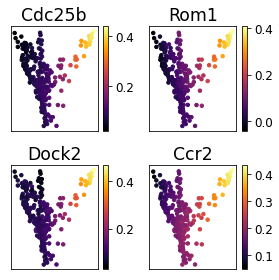

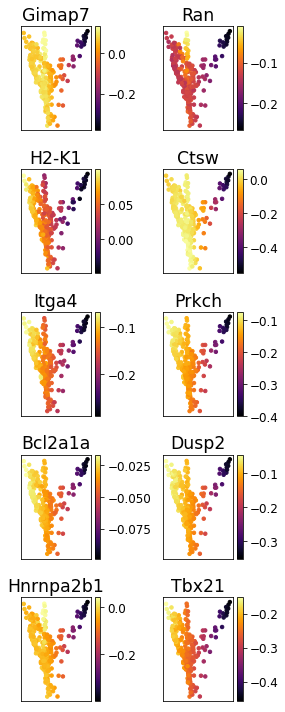

In [18]:
for genes in KO_markers:
    fig, ax = plt.subplots(len(genes)//2,2, figsize=(4,len(genes)//2*2)); ax=ax.flatten()
    for i,gene in enumerate(genes):
        scprep.plot.scatter2d(KO_phate, c=KO_magic[gene], title=gene, ticks=None, ax=ax[i])
    plt.tight_layout()

<AxesSubplot:title={'center':'cell_clusters'}>

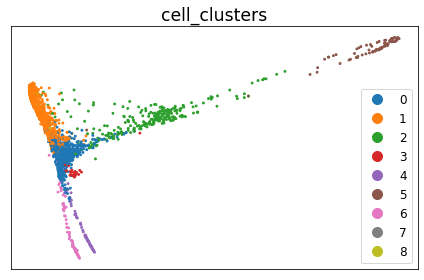

In [11]:
scprep.plot.scatter2d(NEG_phate, c=data_int[guide_hit_signal == 'NEG'].obs['integrated_snn_res.0.3'],
                      title='cell_clusters', ticks=None)

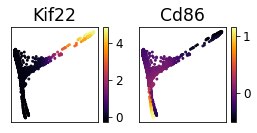

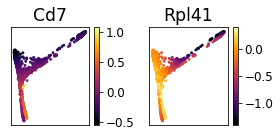

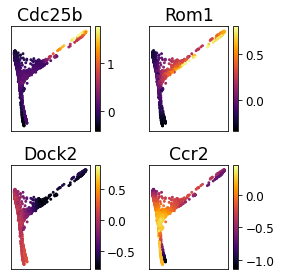

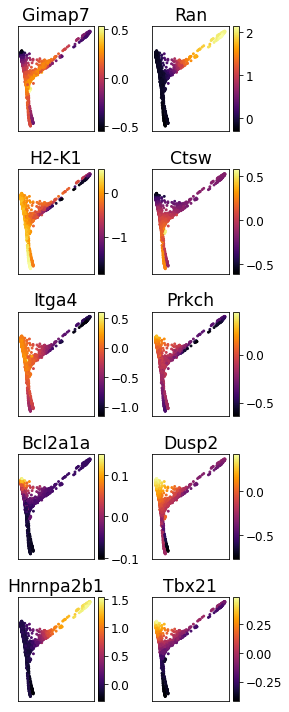

In [19]:
for genes in KO_markers:
    fig, ax = plt.subplots(len(genes)//2,2, figsize=(4,len(genes)//2*2)); ax=ax.flatten()
    for i,gene in enumerate(genes):
        scprep.plot.scatter2d(NEG_phate, c=NEG_magic[gene], title=gene, ticks=None, ax=ax[i])
    plt.tight_layout()

## Edges in normal that are not in perturbation

In [8]:
for guide in guides:
    print (guide)
    threshold = np.percentile(localizations['NEG'], q=75)
    neg_loc = embeddings['NEG'].loc[(localizations['NEG'] > threshold)[0]]
    
    threshold = np.percentile(localizations[guide], q=75)
    KO_loc = embeddings[guide].loc[(localizations[guide] > threshold)[0]]
    
    loc_genes_both = set(neg_loc.index).intersection(KO_loc.index)
    
    G = graphtools.Graph(embeddings['NEG'].loc[loc_genes_both], knn=5, use_pygsp=True)
    G_neg = G.A.todense().astype(int)
    
    G = graphtools.Graph(embeddings[guide].loc[loc_genes_both], knn=100, use_pygsp=True)
    G_KO = G.A.todense().astype(int)
    
    A = G_neg - G_KO
    A = A > 0 # edges that are in sparser neg graph and not in more complete KO graph
    G_neg_only = nx.Graph(A)
    G_neg_only = nx.relabel_nodes(G_neg_only, dict(zip(range(G_neg_only.number_of_nodes()), list(loc_genes_both))))
    
    nx.write_edgelist(G_neg_only, f'results/Figure4g_not_coexpressed_in_KO/{guide}_only_graph.tsv', delimiter='\t', data=False)
    
    for cc in nx.connected_components(G_neg_only):
        if len(cc) > 1:
            print (cc)

BACH2
{'Cblb', 'Gm11579', 'F10', 'Maml2'}
{'Lgals3', 'AI506816'}
{'Pim1', 'Trac', 'Lcn4'}
{'Tnfrsf9', 'Cotl1'}
BATF
{'Rps2', 'Tox'}
{'Rpsa', 'Fchsd2'}
{'Tent5a', 'Gm11579'}
BCL6
{'Dzank1', 'Ifitm3', 'Fmr1nb', 'Adam19', 'Lsp1', 'Nccrp1', 'Klf1'}
{'Tagln2', 'Cmtm7'}
{'Cd5', 'Cd69', 'Apobec3'}
{'Samd13', 'Msc', 'Rdm1', 'Hdgf', 'Cfl1'}
{'Rpl32', 'Itga4'}
{'Ssbp2', 'Zeb1'}
CXCL13
{'Dzank1', 'Cd69', 'Adam19', 'Ms4a4c', 'Apobec3', 'Lsp1', '2310001H17Rik', 'Klf1', 'Trac'}
{'Arhgap15', 'Cblb', 'Ifngr1', 'Gm11579', 'F10', 'Pim1'}
{'Ptma', 'Stmn1'}
{'Dynll1', 'Hsp90b1'}
{'Gm8369', 'Gimap6', 'Rpl12', 'Slfn1'}
{'Neurl3', 'Sntb1', 'Rpsa'}
{'Rcbtb2', 'Trbc1'}
CXCR5
{'Maml2', 'Sdcbp2', 'Fmr1nb', 'Id2', 'Gm11579', 'Gzmm', 'F10', 'Pim1'}
{'Gapdh', 'Tagln2', 'Cmtm7', 'CAAA01147332.1'}
{'Tnfrsf9', 'Rom1', 'Gm29666'}
{'Ptma', 'Lmnb1', 'Hmgn2', 'Cep55'}
{'Gm8369', 'Mbnl1'}
DNMT1
{'Gm4316', '3830403N18Rik'}
{'Rdm1', 'H1fx'}
DNMT3A
{'Rgs10', 'Rpsa'}
{'Fabp5', 'Rad21', 'Samd13', 'Hnrnpa2b1'}
DNMT3B
{'Trac', 'C

In [21]:
KO_markers = [{'Ccr2', 'Ier3', 'Ctsw', 'Sntb1', 'Cd69', 'Plac8', 'Atxn1', 'Tigit', 'Cd44', 'S100a4', 'Il18r1', 'Gimap7', 'Acot7', 'Batf'},
{'Pim2', 'Il7r'},
{'Ifitm3', 'Calhm6', 'Cdc25b', 'Irf8', 'Rom1'},
{'Gm45442', 'Smc1a', 'Hnrnpa2b1'},
{'Itga4', 'Dock2'},
{'Pfn1', 'CAAA01147332.1'},
{'Actg1', '1700097N02Rik', 'Capg'},
{'Ctla2a', 'Emb'},
{'AW112010', 'Ighm', 'Lilr4b'}]

In [2]:
KO_markers = [{'Pdcd1', 'Ifngas1', 'Cd27', 'Bach2', 'Atxn1', 'Adam19', 'Gimap6', 'Armc7', 'S100a4', 'Ly6e', 'Cd7', 'Traf1', 'Lcn4', 'Klhl6', 'Il18r1', 'Fchsd2', 'Shisa5', 'Sntb1', 'Ms4a4b', 'Mbnl1', 'Lilrb4a', 'Cd5', 'Tigit', 'Ly6a', 'Gstp3', 'Apobec3', 'Ifi47', 'Cotl1', 'Gzmm', 'Glrx', 'Trac', 'Dzank1', 'Ctsw', 'Neurl3', 'Rps2', 'Epsti1', 'CAAA01147332.1', 'Ctla4', 'Gimap7', 'Tagln2', 'Ifi208', 'Lilr4b', 'Ier3', 'Hsp90aa1', 'Ighm', 'Plac8', 'Gapdh', 'Id2', 'Pglyrp1', 'Cxcr6', 'F10', 'AW112010', 'Chil5', 'Acot7', 'Cmtm7'},
{'Actg1', 'Pdia6', 'Cdkn2d', 'Emp3', 'Hspa5', 'Hsp90b1', 'Prdx1', 'Gzmb', 'Pycard', 'Smpdl3b', 'Vim', 'Zfp683', 'Cfl1', 'Tmsb10', 'Casp3', 'S100a10', 'Lcp1', '1700097N02Rik', 'Etfb', 'Lgals3', 'Rcbtb2', 'Racgap1', 'Insl6', 'Dap', 'Plek', 'Rap1gap2', 'Fcgr2b', 'H2afz', 'Cyp11a1', 'Actb'}]

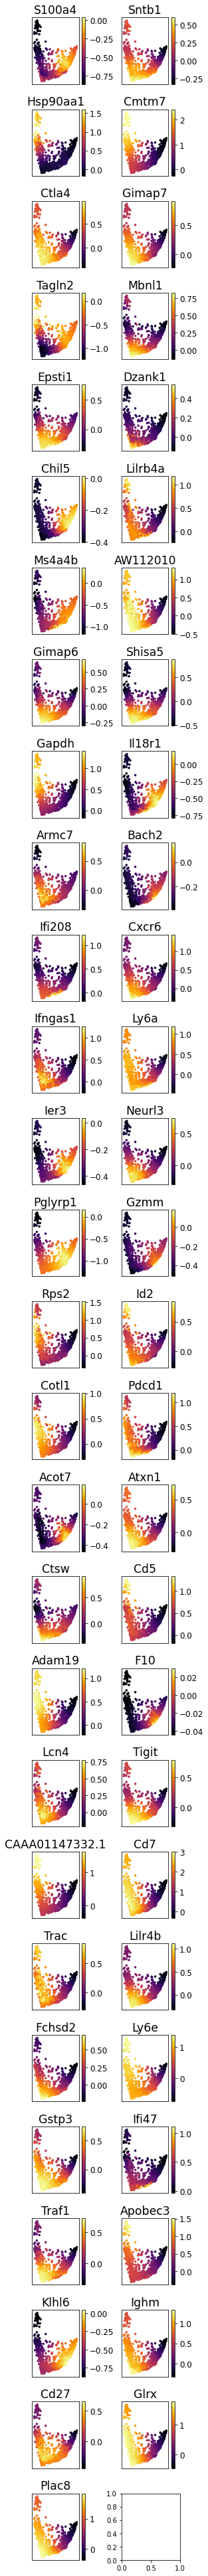

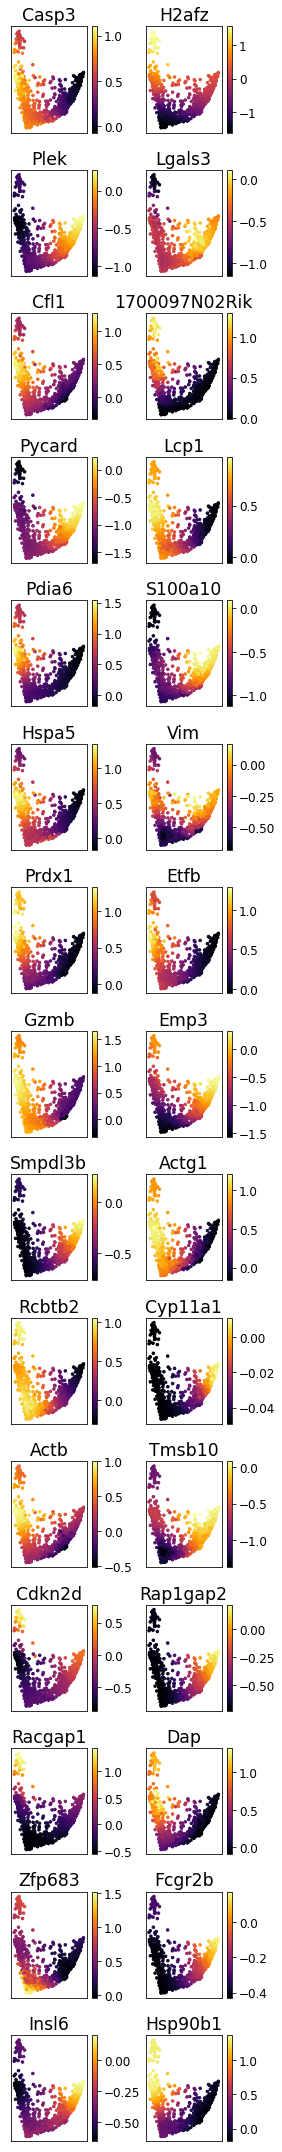

In [10]:
for genes in KO_markers:
    fig, ax = plt.subplots(int(np.ceil(len(genes)/2)),2, figsize=(4,len(genes)//2*2)); ax=ax.flatten()
    for i,gene in enumerate(genes):
        scprep.plot.scatter2d(KO_phate, c=KO_magic[gene], title=gene, ticks=None, ax=ax[i])
    plt.tight_layout()

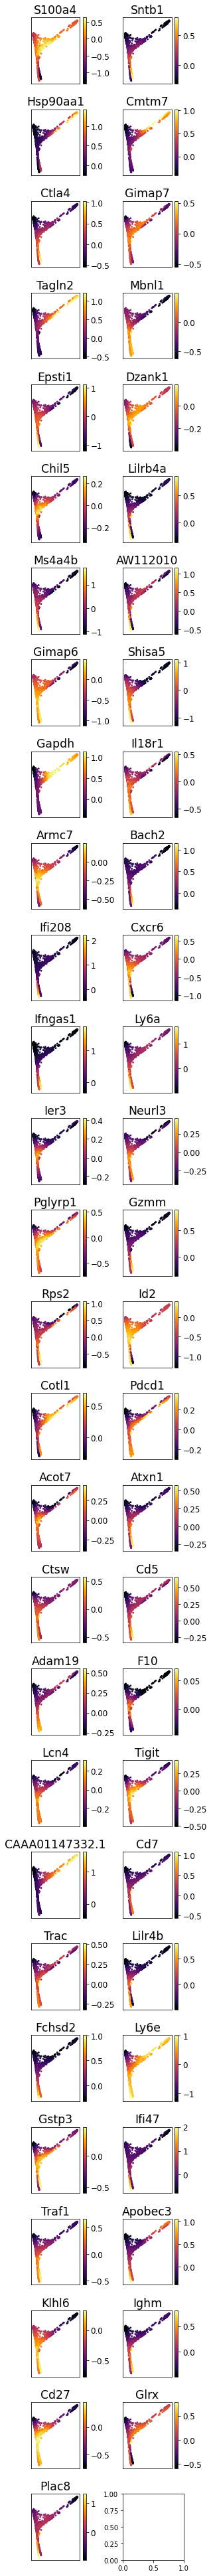

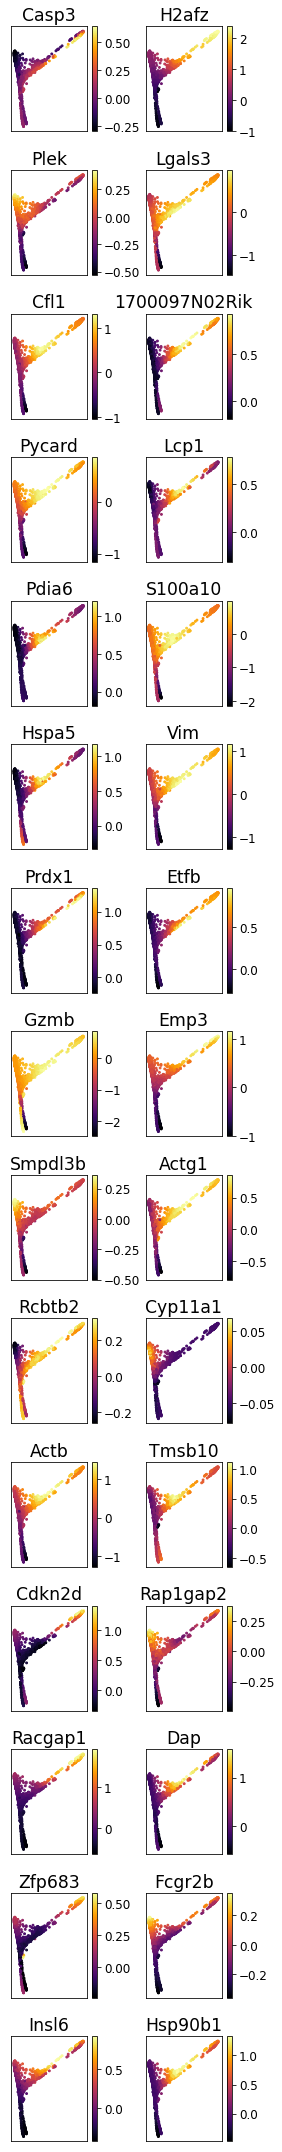

In [11]:
for genes in KO_markers:
    fig, ax = plt.subplots(int(np.ceil(len(genes)/2)),2, figsize=(4,len(genes)//2*2)); ax=ax.flatten()
    for i,gene in enumerate(genes):
        scprep.plot.scatter2d(NEG_phate, c=NEG_magic[gene], title=gene, ticks=None, ax=ax[i])
    plt.tight_layout()